# Clone A Reconstruction

After a reconstruction has been checked and repaired, you may want clean copies for later analysis or experiments. In this tutorial, you will smooth dendrites, resample the reconstruction, and create several clones with the same structure but different dendrite orientations.

## Workflow

```text
sample SWC file
      |
      v
smooth contracted dendrites
      |
      v
center and resample
      |
      v
find bifurcation points
      |
      v
create several clones
      |
      v
view all clones together
```

## Reading the clone commands

These commands are post-processing steps. `swc modify` changes branch geometry, while `swc repair` can center and resample the reconstruction.

| Part | Meaning |
| --- | --- |
| `-m 2` | smooth sections with two iterations |
| `-t T` | stretch sections in their principal direction |
| `-n` | center the reconstruction at the origin |
| `-r 5` | resample with fixed spatial resolution of `5` um |
| `-g2` | find bifurcation points with degree `2` |
| `-w180` | rotate selected branches by random angles from `-180` to `180` degrees |
| `--seed` | make random changes repeatable |
| `clone1.swc clone2.swc clone3.swc` | the clone files to view together |

## Command helper

Run this cell once before the tutorial commands. It creates `shell_cmd()`, a small notebook helper that runs terminal commands, shows their output, and displays images when a command creates one.

In [1]:
import subprocess
from pathlib import Path

from IPython.display import Image, display


def shell_cmd(command, image=None):
    print("Executed command:")
    print(command)
    result = subprocess.run(
        command,
        shell=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )
    output = result.stdout.rstrip()
    print("\nOutput:")
    print(output if output else "(empty)")

    if image is not None and Path(image).exists():
        display(Image(filename=image))


## Copy a sample file

Use the cut NMO reconstruction for post-processing examples.

In [2]:
shell_cmd("cp -v ../tests/data/pass_nmo_2_cut.swc data/")

Executed command:
cp -v ../tests/data/pass_nmo_2_cut.swc data/

Output:
'../tests/data/pass_nmo_2_cut.swc' -> 'data/pass_nmo_2_cut.swc'


## View contracted dendrites

Start by viewing basal dendrites before smoothing.

Executed command:
swc view data/pass_nmo_2_cut.swc -jxy -p3 --no-axes -o output/contracted_dendrites.png

Output:
(empty)


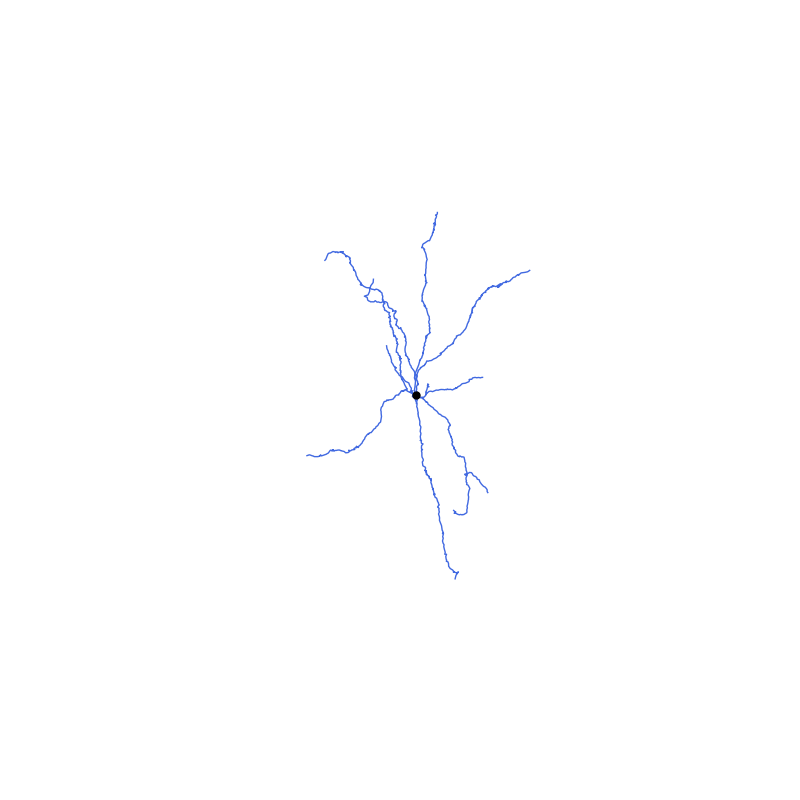

In [3]:
shell_cmd(
    "swc view data/pass_nmo_2_cut.swc -jxy -p3 --no-axes -o output/contracted_dendrites.png",
    image="output/contracted_dendrites.png",
)

## Smooth dendrites

Smoothing can be used as a post-processing step when dendrites are contracted.

Executed command:
swc modify data/pass_nmo_2_cut.swc -p3 -m 2 -o output/fixsmooth.swc

Output:
(empty)
Executed command:
swc view output/fixsmooth.swc data/pass_nmo_2_cut.swc -p3 -c shadow --no-axes -jxy -o output/smooth_compare.png

Output:
(empty)


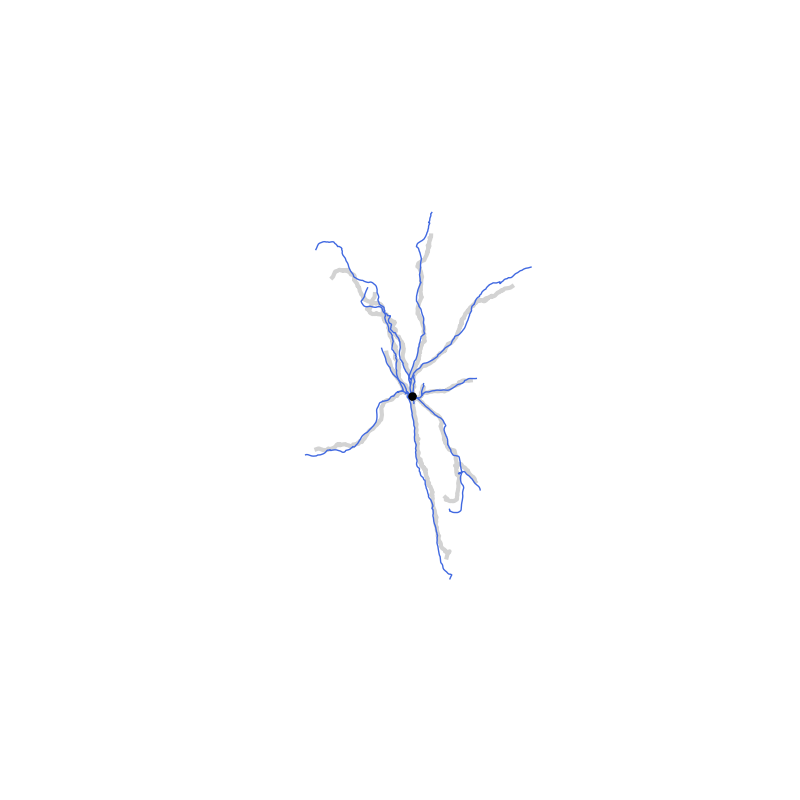

In [4]:
shell_cmd("swc modify data/pass_nmo_2_cut.swc -p3 -m 2 -o output/fixsmooth.swc")
shell_cmd(
    "swc view output/fixsmooth.swc data/pass_nmo_2_cut.swc -p3 -c shadow --no-axes -jxy -o output/smooth_compare.png",
    image="output/smooth_compare.png",
)

Smoothing methods: `-m M` is spatial low-pass filtering where `M` is number of iterations (`M=1,2,...`); `-t T` is section stretching in principal direction where `T` is relative stretching factor (`T>=1`).

## Center and resample

Another post-processing step is centering the finalized reconstruction at the origin with `-n` and resampling it with fixed spatial resolution using `-r R`, for example `5` um.

Executed command:
swc repair data/pass_nmo_2_cut.swc -n -r 5 -o output/fixsample.swc

Output:
(empty)
Executed command:
swc view output/fixsample.swc data/pass_nmo_2_cut.swc -p3 -jxy -c shadow --no-axes -o output/resample_compare.png

Output:
(empty)


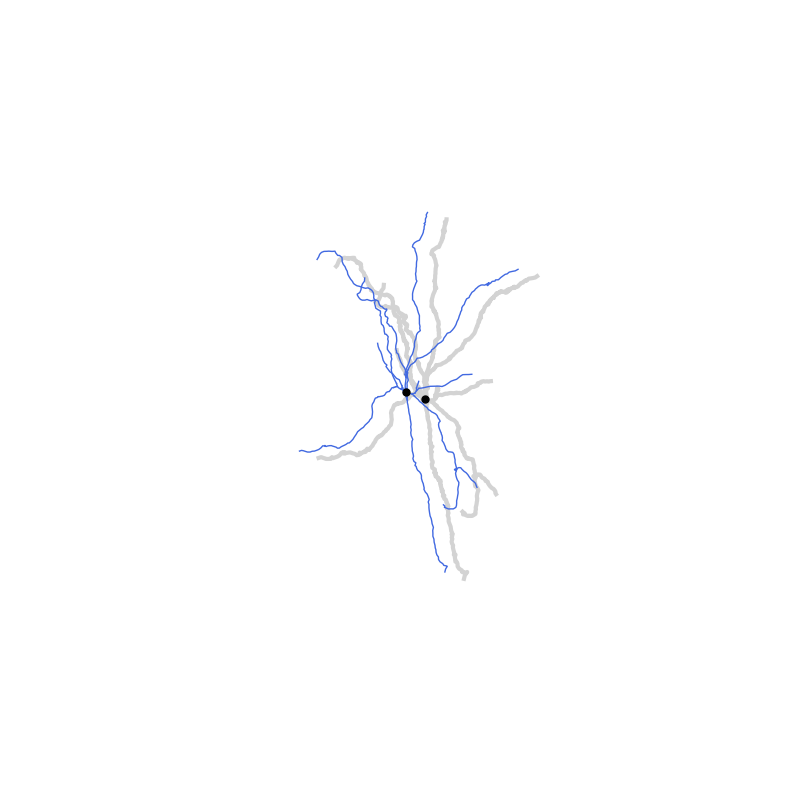

In [5]:
shell_cmd("swc repair data/pass_nmo_2_cut.swc -n -r 5 -o output/fixsample.swc")
shell_cmd(
    "swc view output/fixsample.swc data/pass_nmo_2_cut.swc -p3 -jxy -c shadow --no-axes -o output/resample_compare.png",
    image="output/resample_compare.png",
)

## Find bifurcation points

Create clones of the final morphology that have the same total dendritic length and structure but different orientation of dendritic sections. First find bifurcation points in basal dendrites: point type `3`, degree `2`.

Executed command:
swc find output/fixsample.swc -p3 -g2

Output:
7 161 163 231 276 300 370
Executed command:
swc view output/fixsample.swc -m 7 161 163 231 276 300 370 -p3 -jxy --no-axes -o output/bifurcations.png

Output:
(empty)


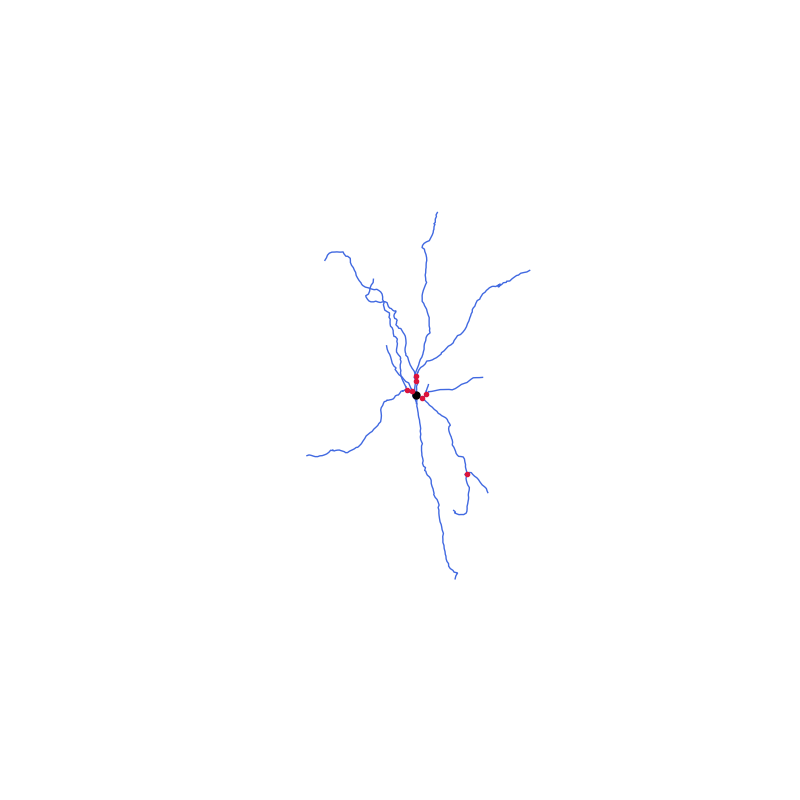

In [6]:
shell_cmd("swc find output/fixsample.swc -p3 -g2")
shell_cmd(
    "swc view output/fixsample.swc -m 7 161 163 231 276 300 370 -p3 -jxy --no-axes -o output/bifurcations.png",
    image="output/bifurcations.png",
)

## Create clone morphologies

Rotate dendritic branches by a random angle from `-180` to `180` degrees at the bifurcation points.

In [7]:
shell_cmd("swc modify output/fixsample.swc -i 7 161 163 231 276 300 370 -w180 --seed 1 -o output/clone1.swc")
shell_cmd("swc modify output/fixsample.swc -i 7 161 163 231 276 300 370 -w180 --seed 2 -o output/clone2.swc")
shell_cmd("swc modify output/fixsample.swc -i 7 161 163 231 276 300 370 -w180 --seed 3 -o output/clone3.swc")

Executed command:
swc modify output/fixsample.swc -i 7 161 163 231 276 300 370 -w180 --seed 1 -o output/clone1.swc

Output:
(empty)
Executed command:
swc modify output/fixsample.swc -i 7 161 163 231 276 300 370 -w180 --seed 2 -o output/clone2.swc

Output:
(empty)
Executed command:
swc modify output/fixsample.swc -i 7 161 163 231 276 300 370 -w180 --seed 3 -o output/clone3.swc

Output:
(empty)


## View clones together

View the original resampled reconstruction and the three clones together.

Executed command:
swc view output/fixsample.swc output/clone1.swc output/clone2.swc output/clone3.swc -p3 -jxy -c cells --no-axes -o output/clones.png

Output:
(empty)


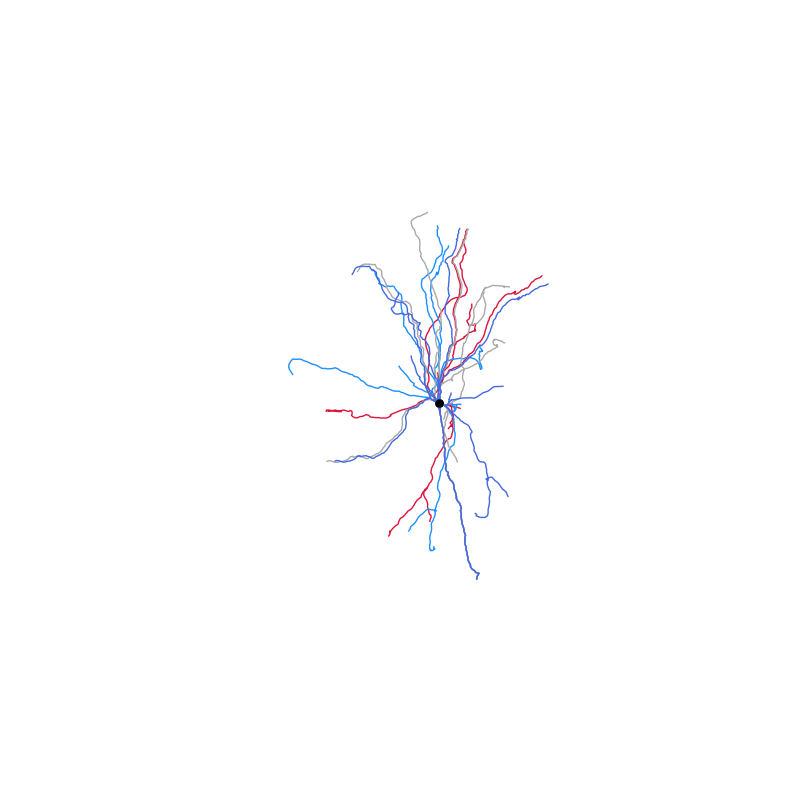

In [8]:
shell_cmd(
    "swc view output/fixsample.swc output/clone1.swc output/clone2.swc output/clone3.swc -p3 -jxy -c cells --no-axes -o output/clones.png",
    image="output/clones.png",
)

Branch twisting can be combined with random jittering (`-j J`) and scaling (`-s X Y Z`). Those changes affect the total dendritic length.